## Seaborn
Seaborn is a python data visualization library based on matplotlib

1. Matplotlib -> use for low level work where we want to controll minute details very deeply

2. Seaborn -> use for high level work we doesnt want too much customization and controll at minute level


### Benefits of Seaborn
1. we got inbuilt dataset
2. we get high level features
3. great support for pandas dataframe
4. boxplots, heatmaps plotting are easier as compared to matplotlib


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
sns.set_theme()  # before using seaborn we set theme means plots will be light mode dark mode and khali chhod do jaisa abhi hai to by default theme select ho jayegi

In [3]:
sns.get_dataset_names() # to get the names of available dataset of seaborn

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
tips = sns.load_dataset("tips") # this is how we load the available dataset of seaborn
print(type(tips))  # it is pandas dataframe
print(tips.head())

<class 'pandas.core.frame.DataFrame'>
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


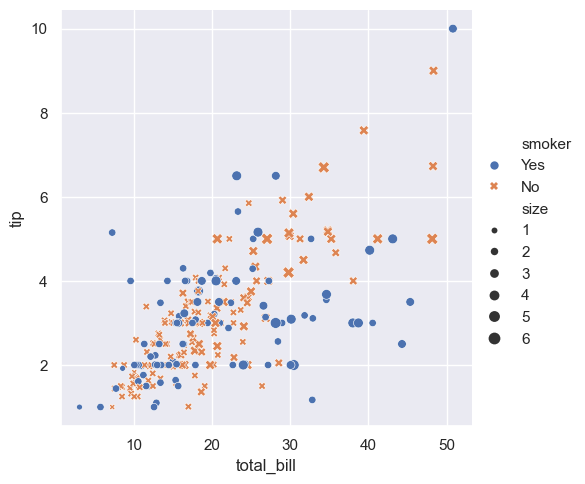

In [12]:
# relational plot
''' 
plots which shows relationship between like scatter plot,line plot
in seaborn we use # relplot for relational plot
by default relplot creates a scatter plot
'''
# lets plot relational plot for bill and tip that how much tip is given for how much bill value
# independ variable on x axis and dependent on y here tip is dependent on bill so tip on y and bill on x axis


sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",  # we have highloghted smoker and nonsmoker
    size="size",  # we got different size of dots on the basis of size column 
    style="smoker" # if we want different style on the basis of smoker and nonsmoker
)

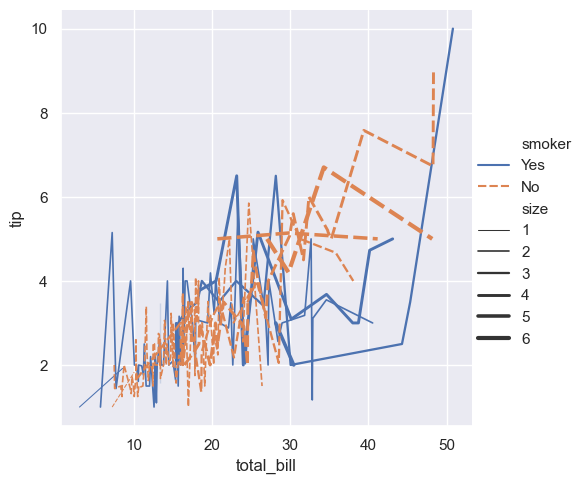

In [13]:
# if we want same but lineplot
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="line",
    hue="smoker",  # we have highloghted smoker and nonsmoker
    size="size",  # we got different size of dots on the basis of size column 
    style="smoker" # if we want different style on the basis of smoker and nonsmoker
)

<Axes: xlabel='total_bill', ylabel='tip'>

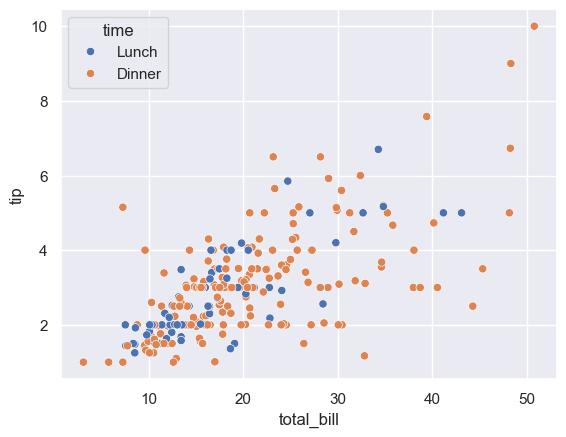

In [20]:
# scatterplot -> show the relationship between tips and bill
sns.scatterplot(
    data = tips,
    x="total_bill",
    y="tip",
    hue="time" # if we want to analyze luch or dinner differently
)

In [14]:
# line plot
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<Axes: xlabel='year', ylabel='passengers'>

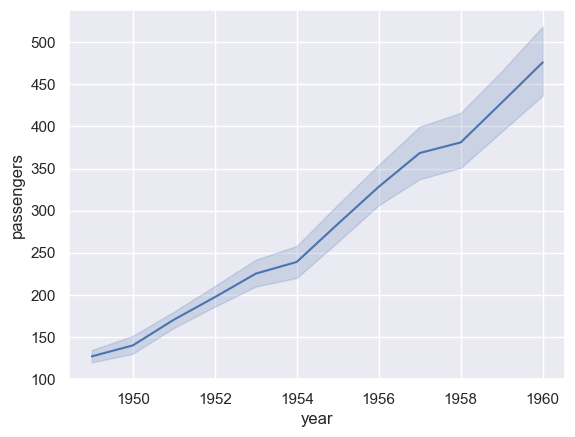

In [22]:
# plot passengers over the year passenger dependent on year
sns.lineplot(
    data=flights,
    x="year",
    y="passengers"
)

<Axes: xlabel='day', ylabel='tip'>

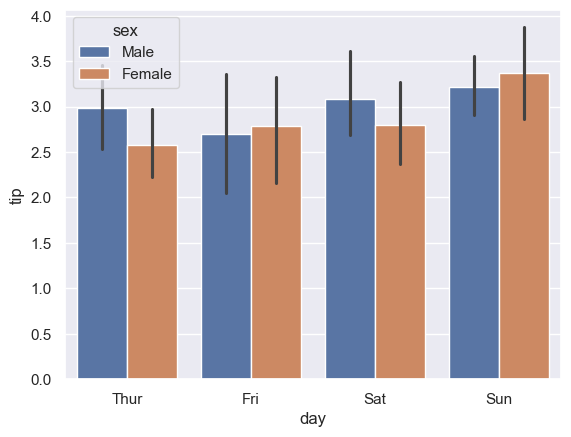

In [23]:
# categorical plot
#1 Bar plot -> in tips how much tips given by female and male over multiple days
sns.barplot(
    data=tips,
    x="day",
    y="tip",
    hue="sex"
)

<Axes: xlabel='day', ylabel='tip'>

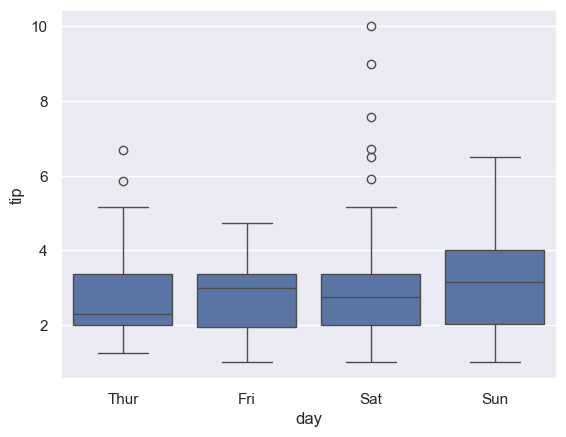

In [25]:
#2 boxplot - over the days kya tip values hai
sns.boxplot(
    data=tips,
    x="day",
    y="tip"
)

In [ ]:
# distribution plot -> to show the distribution of data one of the classical example is histogram
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<Axes: xlabel='body_mass_g', ylabel='Count'>

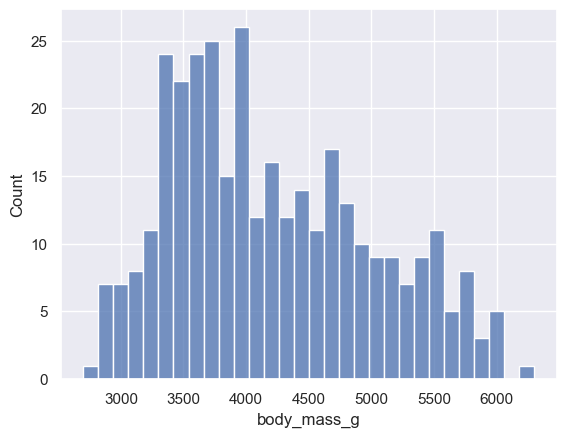

In [29]:
# lets plot histogram of body mass to see what is the distribution of body mass of all the penguins
sns.histplot(
    data=penguins,
    x="body_mass_g",
    bins=30
)


In [30]:
# Matrix Plot
''' 
Heatmaps - plot rectangular data as color-encoded matrix
'''
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [33]:
# let we want to show for every year every particular month 
# me kitne passengers travel kare tp ye 2d type ka data hai like pahle year and year me bhi month then in that kitne passenger to 2d type ka to yeha per heatmap use karenge
''' 
to pahle given data ko 2d type me convert karna hoga
jaha per hear column year ban jaye row month ban jaye 
and in each cell uss year ke uss month ke number of pessangers
ho 
for this we can pivot the dataset
'''
flights_pivot = flights.pivot(index="month",columns="year",values="passengers")

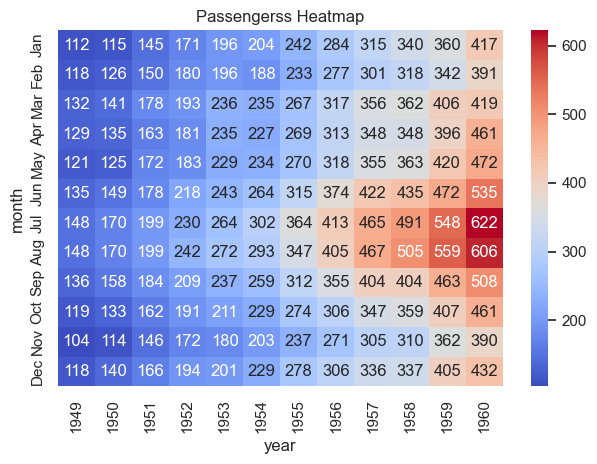

In [37]:
sns.heatmap(
    flights_pivot,
    cmap="coolwarm",
    annot=True,
    fmt="d"
)
plt.title("Passengerss Heatmap")
plt.tight_layout()

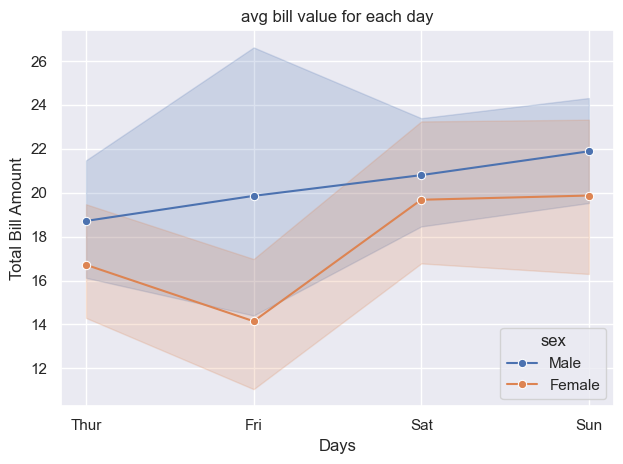

In [42]:
# Best Practices
''' 
generally we plot with the help of seaborn and then
we want any customizations that will be done using 
matplotlib
we use plt.subplots() of matplotlib but individual plots will be
created using seaborn
'''
# lets show her ek din ka totall bill based on gender on tips dataset
fig,ax = plt.subplots()

sns.lineplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    marker='o',
    ax=ax   # to set axis value
)
ax.set_title("avg bill value for each day")
ax.set_xlabel("Days")
ax.set_ylabel("Total Bill Amount")

fig.tight_layout()